# DINOv3 Clean vs Dirty Classification

**Task:** Classify CCTV crops of restaurant tables as `clean` or `dirty`

**Data:** Each sample is `frame_2.jpg` (most recent frame) from a triplet folder produced by the data pipeline.

**Architecture:** DINOv3 backbone (last 2 blocks unfrozen) → CLS token → MLP Head (1024→128→2)

**Key Features:**
- Group-based train/val/test split by video stem (prevents temporal leakage)
- Differential LR: tiny LR for backbone, higher for head
- Focal loss + class weights for imbalanced data
- 5-fold GroupKFold CV for backbone LR selection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_dir = "/content/drive/Shared drives/shire drive"

print(f"Checking path: {base_dir}")
if os.path.exists(base_dir):
    print("\n✅ Success! 'shire drive' found. Here is what is inside:")
    items = os.listdir(base_dir)
    for item in items:
        print(f" - {item}")
else:
    print(f"\n❌ Could not find {base_dir}")


Checking path: /content/drive/Shared drives/shire drive

✅ Success! 'shire drive' found. Here is what is inside:
 - SHIRELABELING


In [ ]:
!pip install -q huggingface_hub
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
import os
import re
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from PIL import Image
from collections import Counter
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from transformers import AutoModel

import warnings
warnings.filterwarnings('ignore')

import sys
print(f"Python version: {sys.version}")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================

DATA_DIR = "/content/drive/Shared drives/shire drive/SHIRELABELING"

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

EMBED_DIMS = {"small": 384, "base": 768, "large": 1024, "huge": 1280}
BACKBONE_SIZE = "large"

BATCH_SIZE = 16
NUM_WORKERS = 0  # Set to 0 to avoid DataLoader worker crashes in Colab
NUM_EPOCHS = 50
LEARNING_RATE = 3e-4
BACKBONE_LR = 1e-06  # Hardcoded as requested
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.1
EARLY_STOPPING_PATIENCE = 10
DROPOUT = 0.3
UNFREEZE_LAST_N = 2  # Freeze backbone entirely!

FOCAL_LOSS_GAMMA = 2.0
USE_CLASS_WEIGHTS = False # Disabled to prevent double-penalty with WeightedRandomSampler

SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load DINOv3 from HuggingFace
from transformers import AutoModel

print(f"Loading DINOv3 {BACKBONE_SIZE} from HuggingFace...")

HF_MODELS = {
    "small": "facebook/dinov3-vits16-pretrain-lvd1689m",
    "base": "facebook/dinov3-vitb16-pretrain-lvd1689m",
    "large": "facebook/dinov3-vitl16-pretrain-lvd1689m",
}

backbone = AutoModel.from_pretrained(HF_MODELS[BACKBONE_SIZE], trust_remote_code=True)

embed_dim = EMBED_DIMS[BACKBONE_SIZE]
print(f"Embed dim: {embed_dim}")
print(f"Backbone params: {sum(p.numel() for p in backbone.parameters()):,}")

Loading DINOv3 small from HuggingFace...


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Embed dim: 384
Backbone params: 21,596,544


In [ ]:
# Discover samples: each triplet folder contributes one sample (frame_2.jpg) for clean,
# but for dirty we take all 3 frames as requested.
CLASSES = ['clean', 'dirty']
num_classes = len(CLASSES)
id2label = {i: c for i, c in enumerate(CLASSES)}
label2id = {c: i for i, c in id2label.items()}

samples = []  # list of (frame_path, label_idx, folder_name)
for label_name in CLASSES:
    label_dir = os.path.join(DATA_DIR, label_name)
    if not os.path.isdir(label_dir):
        print(f"WARNING: {label_dir} not found, skipping")
        continue
    for folder_name in sorted(os.listdir(label_dir)):
        folder_path = os.path.join(label_dir, folder_name)
        if not os.path.isdir(folder_path):
            continue

        if label_name == 'dirty':
            # Sample frames 0, 1, and 2 for dirty images
            for frame_num in [0, 1, 2]:
                frame_path = os.path.join(folder_path, f"frame_{frame_num}.jpg")
                if os.path.exists(frame_path):
                    samples.append((frame_path, label2id[label_name], folder_name))
        else:
            # Only sample frame 2 for clean images
            frame_path = os.path.join(folder_path, "frame_2.jpg")
            if os.path.exists(frame_path):
                samples.append((frame_path, label2id[label_name], folder_name))

labels = [s[1] for s in samples]
folder_names = [s[2] for s in samples]

print(f"Classes: {CLASSES}")
print(f"Total samples: {len(samples)}")

class_counts = Counter(labels)
print("\nClass distribution:")
for idx, count in sorted(class_counts.items()):
    print(f"  {id2label[idx]}: {count} ({100*count/len(samples):.1f}%)")

Classes: ['clean', 'dirty']
Total samples: 2112

Class distribution:
  clean: 2041 (96.6%)
  dirty: 71 (3.4%)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

def get_group_id(folder_name):
    """Group by video_stem + table_id (strip triplet index).

    e.g. 'IPC11_2024-01-15_table_top_5_t0003' -> 'IPC11_2024-01-15_table_top_5'
    All triplets from the same video+table stay in the same split.
    """
    return re.sub(r"_t\d{4}$", "", folder_name)

indices = list(range(len(samples)))
groups = [get_group_id(folder_names[i]) for i in indices]
unique_groups = set(groups)
print(f"Found {len(unique_groups)} unique video+table groups across {len(indices)} samples")

# Group-based split: all triplets from same video+table go to same split
gss_train = GroupShuffleSplit(n_splits=1, test_size=(VAL_RATIO + TEST_RATIO), random_state=SEED)
train_idx, temp_idx = next(gss_train.split(indices, labels, groups))
train_idx, temp_idx = list(train_idx), list(temp_idx)

temp_groups = [groups[i] for i in temp_idx]
temp_labels = [labels[i] for i in temp_idx]
gss_valtest = GroupShuffleSplit(n_splits=1, test_size=TEST_RATIO/(VAL_RATIO+TEST_RATIO), random_state=SEED)
val_idx_rel, test_idx_rel = next(gss_valtest.split(range(len(temp_idx)), temp_labels, temp_groups))
val_idx = [temp_idx[i] for i in val_idx_rel]
test_idx = [temp_idx[i] for i in test_idx_rel]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# Verify no group leakage
train_groups = set(groups[i] for i in train_idx)
val_groups = set(groups[i] for i in val_idx)
test_groups = set(groups[i] for i in test_idx)
assert len(train_groups & val_groups) == 0, "Leakage between train and val!"
assert len(train_groups & test_groups) == 0, "Leakage between train and test!"
assert len(val_groups & test_groups) == 0, "Leakage between val and test!"
print("No group leakage detected")

# Class weights for imbalanced data
train_labels = [labels[i] for i in train_idx]
train_class_counts = Counter(train_labels)
class_weights = torch.tensor([len(train_labels)/(num_classes*train_class_counts[i]) for i in range(num_classes)], dtype=torch.float32).to(device)
sample_weights = [class_weights[labels[i]].item() for i in train_idx]
print(f"Class weights: {class_weights.tolist()}")

Found 122 unique video+table groups across 2112 samples
Train: 1522 | Val: 268 | Test: 322
No group leakage detected
Class weights: [0.5080106854438782, 31.70833396911621]


In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Refined Augmentation: Protects the 'dirty' features while preventing memorization
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Less aggressive crop to keep table context
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5), # Subtle rotation only
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1), # Helps model focus on texture/shapes over color
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)), # Reduced blur to keep crumbs visible
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.05)), # Smaller erasing to avoid covering the 'dirt'
])

class DINOv3Dataset(torch.utils.data.Dataset):
    def __init__(self, samples, indices, transform=None):
        self.samples = samples
        self.indices = indices
        self.transform = transform or val_transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        path, label, _ = self.samples[self.indices[idx]]
        img = Image.open(path)
        if img.mode != "RGB": img = img.convert("RGB")
        return self.transform(img), label

train_ds = DINOv3Dataset(samples, train_idx, transform=train_transform)
val_ds = DINOv3Dataset(samples, val_idx)
test_ds = DINOv3Dataset(samples, test_idx)

dirty_boost_factor = 1.5
adjusted_sample_weights = [
    w * dirty_boost_factor if labels[train_idx[i]] == 1 else w
    for i, w in enumerate(sample_weights)
]

epoch_length = len(train_idx)
sampler = WeightedRandomSampler(adjusted_sample_weights, epoch_length, replacement=True)
train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
print(f"Batches - Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches - Train: 95 (Oversampled 1x) | Val: 17 | Test: 21


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha, self.gamma, self.label_smoothing = alpha, gamma, label_smoothing
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        fl = (1-pt)**self.gamma * ce
        return (self.alpha[targets] * fl if self.alpha is not None else fl).mean()

In [ ]:
class DINOv3Classifier(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes, dropout=0.15, unfreeze_last_n=0):
        super().__init__()
        self.backbone = backbone
        self.unfreeze_last_n = unfreeze_last_n

        # Freeze entire backbone first
        for p in backbone.parameters():
            p.requires_grad = False

        # Selectively unfreeze last N encoder blocks
        if unfreeze_last_n > 0:
            # Try different attribute paths for DINOv3/ViT encoders
            if hasattr(backbone, 'vit'):
                encoder_layers = backbone.vit.encoder.layer
            elif hasattr(backbone, 'encoder'):
                encoder_layers = backbone.encoder.layer
            else:
                # Fallback for some DINOv3 implementations
                encoder_layers = backbone.layers if hasattr(backbone, 'layers') else []

            if encoder_layers:
                for layer in encoder_layers[-unfreeze_last_n:]:
                    for p in layer.parameters():
                        p.requires_grad = True

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
        self.embed_dim = embed_dim

    def get_backbone_params(self):
        return [p for p in self.backbone.parameters() if p.requires_grad]

    def forward(self, x):
        if self.unfreeze_last_n > 0:
            out = self.backbone(x)
        else:
            with torch.no_grad():
                out = self.backbone(x)

        if hasattr(out, 'last_hidden_state'):
            cls_token = out.last_hidden_state[:, 0]
        elif isinstance(out, dict) and 'x_norm_clstoken' in out:
            cls_token = out['x_norm_clstoken']
        else:
            # Handle cases where output might be a tensor or different object
            cls_token = out[0][:, 0] if isinstance(out, (list, tuple)) else out[:, 0]

        return self.head(cls_token)

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        if self.unfreeze_last_n > 0:
            if hasattr(self.backbone, 'vit'):
                layers = self.backbone.vit.encoder.layer
            elif hasattr(self.backbone, 'encoder'):
                layers = self.backbone.encoder.layer
            else:
                layers = getattr(self.backbone, 'layers', [])

            for layer in layers[-self.unfreeze_last_n:]:
                layer.train(mode)
        return self


In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience, self.counter, self.best_score, self.best_state = patience, 0, None, None
    def __call__(self, val_metric, model):
        if self.best_score is None or val_metric > self.best_score + 0.001:
            self.best_score, self.best_state, self.counter = val_metric, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            self.counter += 1
        return self.counter >= self.patience

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, preds, labels = 0, [], []
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(logits.argmax(1).cpu().numpy())
        labels.extend(y.cpu().numpy())

    acc = accuracy_score(labels, preds)
    rec = recall_score(labels, preds, zero_division=0)
    prec = precision_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, average='macro')
    return total_loss/len(loader), f1, acc, prec, rec

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, preds, labels = 0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += criterion(logits, y).item()
        preds.extend(logits.argmax(1).cpu().numpy())
        labels.extend(y.cpu().numpy())

    acc = accuracy_score(labels, preds)
    rec = recall_score(labels, preds, zero_division=0)
    prec = precision_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, average='macro')
    return total_loss/len(loader), f1, acc, prec, rec, preds, labels

In [ ]:
def train_model(model, train_loader, val_loader, config, device):
    model = model.to(device)
    # Use alpha=None since we are already using a WeightedRandomSampler
    # Double-dipping causes the model to over-index and memorize the minority class
    criterion = FocalLoss(alpha=None, gamma=FOCAL_LOSS_GAMMA, label_smoothing=LABEL_SMOOTHING)

    # Differential LR: backbone unfrozen params get a much smaller LR
    param_groups = [{'params': list(model.head.parameters()), 'lr': config['lr']}]
    backbone_params = model.get_backbone_params()
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': config['backbone_lr']})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=config['weight_decay'])
    total_steps = len(train_loader) * config['epochs']
    warmup_steps = int(WARMUP_RATIO * total_steps)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda s: s/warmup_steps if s < warmup_steps else 0.5*(1+np.cos(np.pi*(s-warmup_steps)/(total_steps-warmup_steps))),
    )
    early_stopping = EarlyStopping(EARLY_STOPPING_PATIENCE)

    for epoch in range(config['epochs']):
        train_loss, train_f1, train_acc, train_prec, train_rec = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
        val_loss, val_f1, val_acc, val_prec, val_rec, _, _ = evaluate(model, val_loader, criterion, device)
        print(f"Epoch {epoch+1}:")
        print(f"  Train -> Macro F1: {100*train_f1:.1f}% | Acc: {100*train_acc:.1f}% | Prec (Dirty): {100*train_prec:.1f}% | Rec (Dirty): {100*train_rec:.1f}%")
        print(f"  Val   -> Macro F1: {100*val_f1:.1f}% | Acc: {100*val_acc:.1f}% | Prec (Dirty): {100*val_prec:.1f}% | Rec (Dirty): {100*val_rec:.1f}%")

        if early_stopping(val_f1, model):
            print(f"Early stopping at epoch {epoch+1}")
            break
    model.load_state_dict(early_stopping.best_state)
    return model.to(device), early_stopping.best_score


In [ ]:
# 5-fold GroupKFold CV removed as requested.
# We are directly using BACKBONE_LR = 1e-06

print(f"Skipping CV. Selected backbone LR is hardcoded to: {BACKBONE_LR:.0e}")


Skipping CV. Selected backbone LR is hardcoded to: 1e-06


In [ ]:
# Full training with selected backbone LR
set_seed(SEED)
model = DINOv3Classifier(backbone, embed_dim, num_classes, dropout=DROPOUT, unfreeze_last_n=UNFREEZE_LAST_N)
print(f"Head params: {sum(p.numel() for p in model.head.parameters()):,}")
print(f"Unfrozen backbone params: {sum(p.numel() for p in model.get_backbone_params()):,}")
print(f"Head LR: {LEARNING_RATE}, Backbone LR: {BACKBONE_LR}")

config = {'epochs': NUM_EPOCHS, 'lr': LEARNING_RATE, 'backbone_lr': BACKBONE_LR, 'weight_decay': WEIGHT_DECAY}
model, best_f1 = train_model(model, train_loader, val_loader, config, device)
print(f"\nBest val Macro F1: {100*best_f1:.2f}%")

Head params: 25,538
Unfrozen backbone params: 0
Head LR: 0.0003, Backbone LR: 1e-06


  0%|          | 0/95 [00:00<?, ?it/s]

Epoch 1:
  Train -> Macro F1: 62.6% | Acc: 68.4% | Prec (Dirty): 74.8% | Rec (Dirty): 79.9%
  Val   -> Macro F1: 27.5% | Acc: 34.3% | Prec (Dirty): 2.8% | Rec (Dirty): 100.0%


  0%|          | 0/95 [00:00<?, ?it/s]

Epoch 2:
  Train -> Macro F1: 89.6% | Acc: 91.5% | Prec (Dirty): 89.7% | Rec (Dirty): 98.9%
  Val   -> Macro F1: 46.2% | Acc: 71.3% | Prec (Dirty): 5.0% | Rec (Dirty): 80.0%


...

Epoch 25:
  Train -> Macro F1: 99.9% | Acc: 99.9% | Prec (Dirty): 99.9% | Rec (Dirty): 100.0%
  Val   -> Macro F1: 56.6% | Acc: 95.9% | Prec (Dirty): 12.5% | Rec (Dirty): 20.0%


  0%|          | 0/95 [00:00<?, ?it/s]

Epoch 26:
  Train -> Macro F1: 99.9% | Acc: 99.9% | Prec (Dirty): 99.8% | Rec (Dirty): 100.0%
  Val   -> Macro F1: 58.4% | Acc: 94.0% | Prec (Dirty): 13.3% | Rec (Dirty): 40.0%


  0%|          | 0/95 [00:00<?, ?it/s]

Epoch 27:
  Train -> Macro F1: 99.9% | Acc: 99.9% | Prec (Dirty): 99.9% | Rec (Dirty): 100.0%
  Val   -> Macro F1: 59.2% | Acc: 97.0% | Prec (Dirty): 20.0% | Rec (Dirty): 20.0%
Early stopping at epoch 27

Best val Macro F1: 60.45%


Calculating probabilities...
Optimal decision threshold based on Val set: 0.4136

Test Accuracy (Adjusted Threshold): 87.58%

              precision    recall  f1-score   support

       clean       0.93      0.93      0.93       280
       dirty       0.53      0.50      0.51        42

    accuracy                           0.88       322
   macro avg       0.73      0.72      0.72       322
weighted avg       0.87      0.88      0.87       322



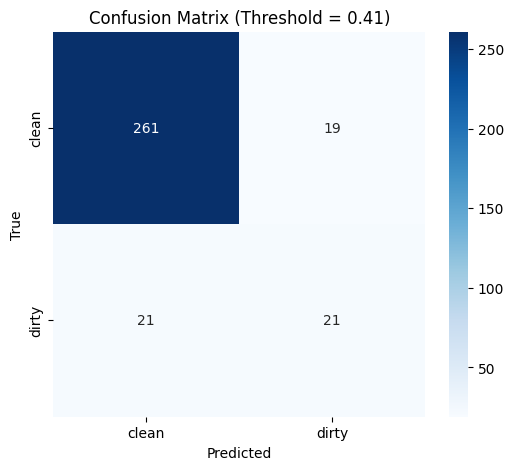

In [ ]:
# Test with Optimal Threshold Tuning
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

@torch.no_grad()
def get_probabilities(model, loader, device):
    model.eval()
    probs, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        # Get probabilities for class 1 ('dirty')
        prob = torch.softmax(logits, dim=1)[:, 1]
        probs.extend(prob.cpu().numpy())
        all_labels.extend(y.numpy())
    return np.array(probs), np.array(all_labels)

print("Calculating probabilities...")
val_probs, val_labels = get_probabilities(model, val_loader, device)

# Find the optimal threshold on the validation set
precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
# Calculate F1 score for each threshold, adding epsilon to avoid division by zero
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"Optimal decision threshold based on Val set: {best_threshold:.4f}\n")

# Apply optimal threshold to test set
test_probs, test_labels = get_probabilities(model, test_loader, device)
test_preds_adjusted = (test_probs >= best_threshold).astype(int)

test_acc_adjusted = np.mean(test_preds_adjusted == test_labels)
print(f"Test Accuracy (Adjusted Threshold): {100*test_acc_adjusted:.2f}%\n")
print(classification_report(test_labels, test_preds_adjusted, target_names=list(id2label.values())))

cm = confusion_matrix(test_labels, test_preds_adjusted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=id2label.values(), yticklabels=id2label.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.2f})')
plt.show()

In [ ]:
# Save the entire model (Backbone + Head)
save_dict = {
    'model_state_dict': model.state_dict(),
    'backbone_config': HF_MODELS[BACKBONE_SIZE],
    'embed_dim': embed_dim,
    'id2label': id2label,
    'unfreeze_last_n': UNFREEZE_LAST_N,
}
torch.save(save_dict, 'dinov3_classifier_full.pt')
print("Full model saved to dinov3_classifier_full.pt")

Full model saved to dinov3_classifier_full.pt
